# Анализ продаж интернет-магазина


# Содержание

1. Цель проекта
2. Загрузка данных
3. Исследование структуры данных
4. Очистка данных
5. Основные KPI
6. Анализ категорий товаров
7. Анализ регионов
8. Анализ скидок
9. Анализ сезонности
10. Анализ клиентов
11. Итоговые выводы
12. Рекомендации бизнесу


## 1.Цель проекта

Провести исследовательский анализ данных интернет-магазина, выявить факторы, влияющие на продажи и прибыль, а также сформулировать рекомендации для бизнеса.

## Используемые инструменты

- Python
- Pandas
- NumPy
- Matplotlib

# 2.Загрузка данных

В качестве источника используется датасет **Sample Superstore**, содержащий информацию о заказах интернет-магазина.

Датасет включает сведения о клиентах, товарах, продажах, прибыли, скидках и регионах

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)

pd.set_option("display.max_columns", None)

In [ ]:
df = pd.read_csv("Sample - Superstore.csv", encoding='windows-1252')

# 3. Исследование структуры данных

Ознакомимся со структурой набора данных и убедимся, что столбцы содержат ожидаемую информацию.

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df.shape

(9994, 21)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

### Вывод

Датасет содержит **9994 записи** и **21 признак**.

Типы данных в целом корректны, однако столбцы **Order Date** и **Ship Date** требуют преобразования в формат datetime.

# 4. Очистка данных

In [7]:
df.isna().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [11]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [13]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Year,Month
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355,2016-05-03 23:06:58.571142,55190.379428,229.858001,3.789574,0.156203,28.656896,2015.722233,7.809686
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,2014.000000,1.000000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,2015.000000,5.000000
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,2016.000000,9.000000
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,2017.000000,11.000000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,2017.000000,12.000000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,1.123555,3.284654


## Выводы по качеству данных

- Пропущенные значения отсутствуют.
- Полных дубликатов не обнаружено.
- Типы данных приведены к корректному виду.
- Распределение продаж имеет выраженную правостороннюю асимметрию: большинство заказов имеют небольшую стоимость, но встречаются крупные покупки.
- В данных присутствуют как высокоприбыльные, так и убыточные заказы.
- Максимальная скидка составляет 80 %, что может существенно влиять на прибыльность продаж.

# Бизнес-вопросы

В рамках проекта необходимо ответить на следующие вопросы:

1. Каковы основные показатели эффективности магазина?
2. Какие категории и подкатегории товаров приносят наибольшую прибыль?
3. Какие регионы и штаты являются наиболее прибыльными?
4. Как скидки влияют на прибыль?
5. Наблюдается ли сезонность продаж?
6. Кто является наиболее ценными клиентами?
7. Какие рекомендации можно дать бизнесу по результатам анализа?

# Основные показатели деятельности магазина
# 5. Основные KPI

In [41]:
# Общая выручка
total_sales = df["Sales"].sum()

# Общая прибыль
total_profit = df["Profit"].sum()

# Количество заказов
orders = df["Order ID"].nunique()

# Количество клиентов
customers = df["Customer ID"].nunique()

# Средняя сумма продажи
average_sale = df["Sales"].mean()


In [15]:
kpi = pd.DataFrame({
    "Показатель": [
        "Общая выручка",
        "Общая прибыль",
        "Количество заказов",
        "Количество клиентов",
        "Средняя сумма продажи"
    ],
    "Значение": [
        round(total_sales, 2),
        round(total_profit, 2),
        orders,
        customers,
        round(average_sale, 2)
    ]
})

kpi

,Показатель,Значение
0,Общая выручка,2297200.86
1,Общая прибыль,286397.02
2,Количество заказов,5009.00
3,Количество клиентов,793.00
4,Средняя сумма продажи,229.86


# 6. Анализ категорий товаров

Цель раздела — определить, какие категории товаров обеспечивают наибольшую выручку и прибыль.

In [23]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

In [24]:
category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

category_profit

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

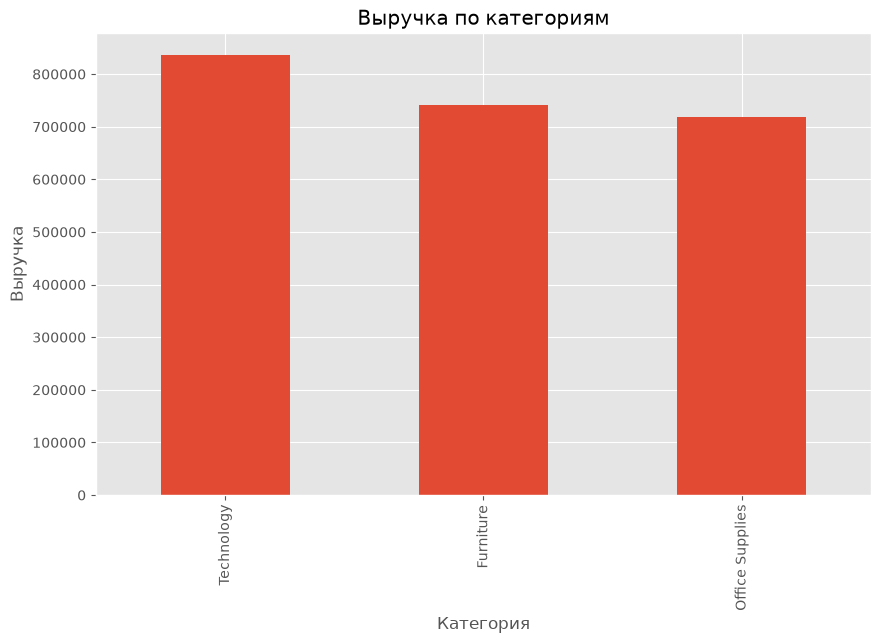

In [25]:
category_sales.plot(
    kind="bar",
    title="Выручка по категориям",
    xlabel="Категория",
    ylabel="Выручка"
)


plt.show()

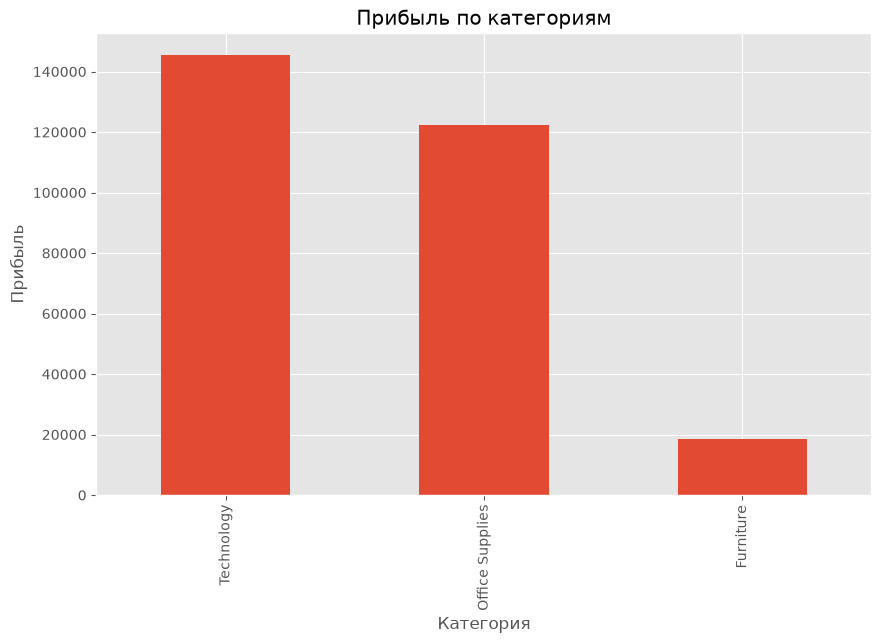

In [26]:
category_profit.plot(
    kind="bar",
    title="Прибыль по категориям",
    xlabel="Категория",
    ylabel="Прибыль"
)

plt.show()

### Вывод

Категория Technology обеспечивает наибольшую прибыль компании.

Категория Furniture имеет высокую выручку, однако её прибыль значительно ниже, что может быть связано с высокой себестоимостью или предоставлением крупных скидок.

Рекомендуется подробнее исследовать причины низкой прибыльности категории Furniture.

# Анализ подкатегорий товаров

На предыдущем этапе были рассмотрены категории товаров.

Теперь определим, какие именно подкатегории являются наиболее прибыльными и какие требуют внимания.

In [42]:
subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

subcategory_sales

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64

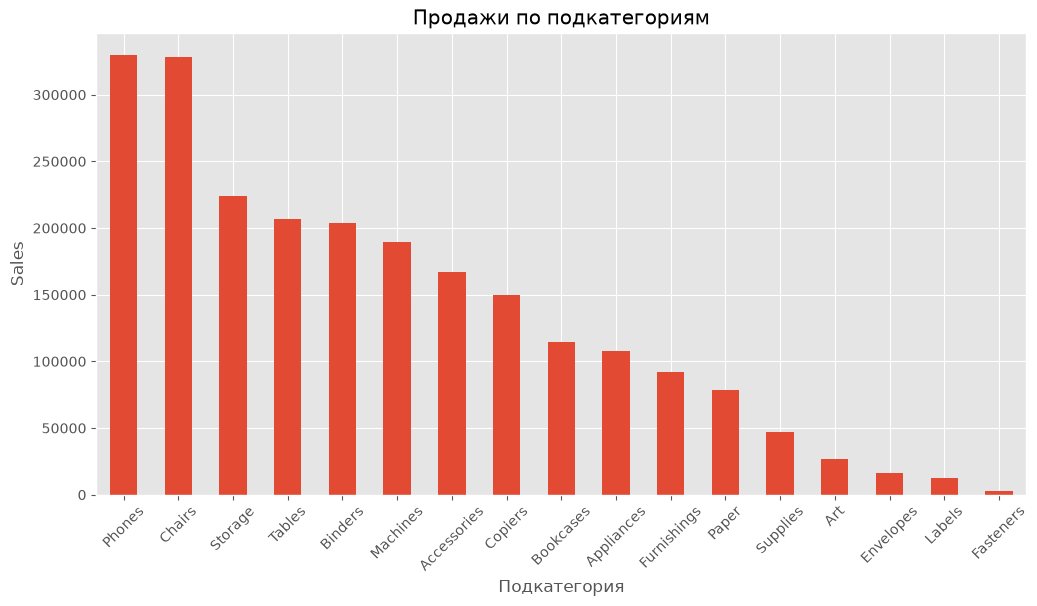

In [43]:
plt.figure(figsize=(12,6))

subcategory_sales.plot(kind="bar")

plt.title("Продажи по подкатегориям")

plt.xlabel("Подкатегория")

plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

In [44]:
subcategory_profit = (
    df.groupby("Sub-Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

subcategory_profit

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64

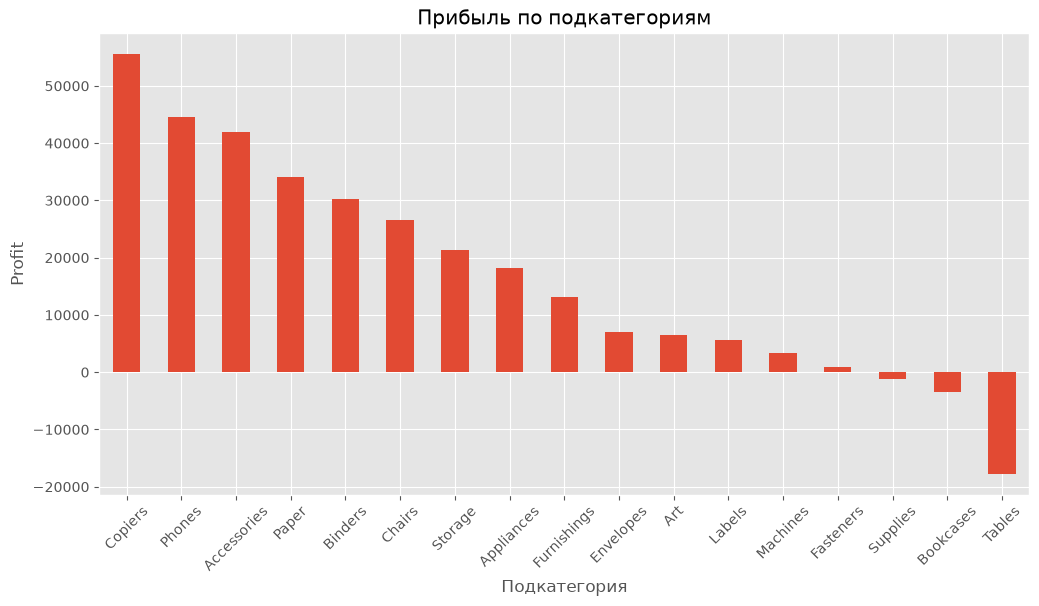

In [45]:
plt.figure(figsize=(12,6))

subcategory_profit.plot(kind="bar")

plt.title("Прибыль по подкатегориям")

plt.xlabel("Подкатегория")

plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.show()

In [47]:
loss = (
    subcategory_profit
        .loc[subcategory_profit < 0]
        .sort_values()
)

loss

Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Name: Profit, dtype: float64

### Вывод

Несмотря на высокий объем продаж отдельных подкатегорий, не все из них являются прибыльными.

Подкатегории с отрицательной прибылью требуют дополнительного анализа. Возможные причины:

- высокая себестоимость;
- чрезмерные скидки;
- низкая маржинальность продукции.

Рекомендуется провести детальный анализ данных товаров.

# 7. Анализ регионов

После анализа категорий товаров необходимо определить географические особенности продаж.

В рамках данного раздела будут рассмотрены следующие вопросы:

- Какие регионы обеспечивают наибольшую выручку?
- Какие регионы наиболее прибыльны?
- Существуют ли регионы с высокой выручкой, но низкой прибылью?

In [48]:
region_sales = (
    df.groupby("Region", as_index=False)
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique")
      )
)

region_sales

,Region,Sales,Profit,Orders
0,Central,501239.8908,39706.3625,1175
1,East,678781.2400,91522.7800,1401
2,South,391721.9050,46749.4303,822
3,West,725457.8245,108418.4489,1611


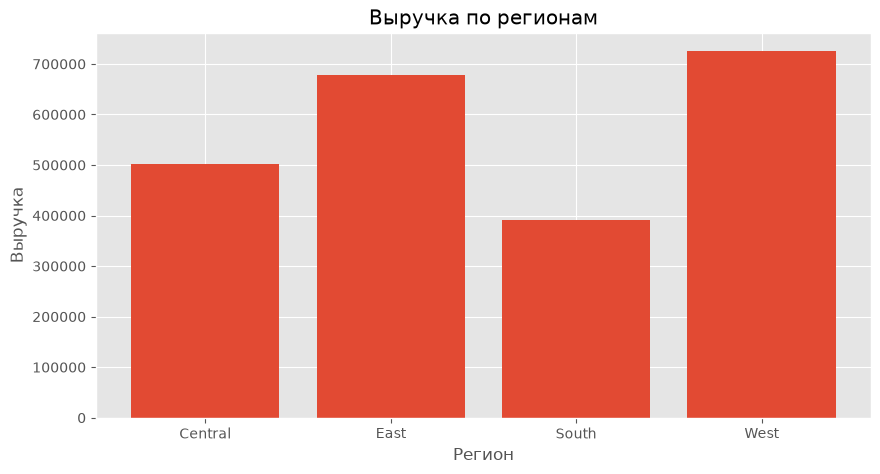

In [49]:
plt.figure(figsize=(10,5))

plt.bar(region_sales["Region"], region_sales["Sales"])

plt.title("Выручка по регионам")
plt.xlabel("Регион")
plt.ylabel("Выручка")

plt.show()

### Вывод

Диаграмма показывает распределение выручки между регионами.

Однако высокий объем продаж еще не означает высокую прибыль. Далее сравним прибыльность регионов.

In [50]:
region_profit = (
    df.groupby("Region")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

region_profit

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

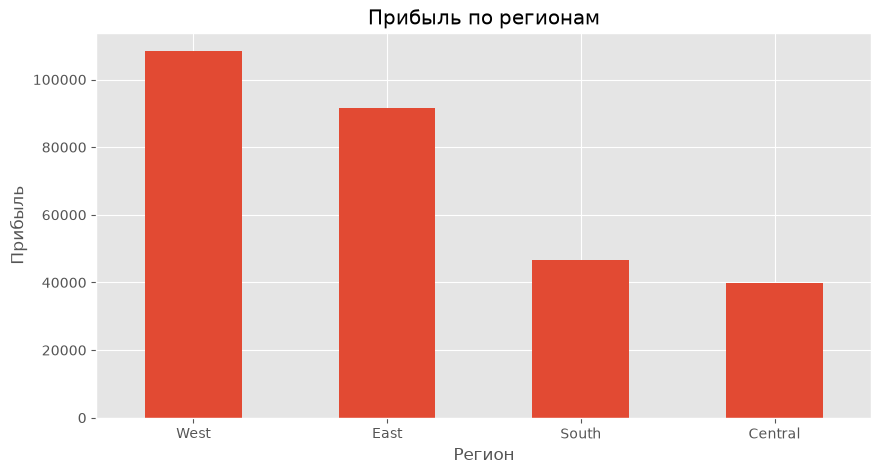

In [51]:
plt.figure(figsize=(10,5))

region_profit.plot(kind="bar")

plt.title("Прибыль по регионам")

plt.xlabel("Регион")

plt.ylabel("Прибыль")

plt.xticks(rotation=0)

plt.show()

### Вывод

Наиболее прибыльные регионы обеспечивают основную часть прибыли компании.

Если регион имеет высокую выручку, но сравнительно низкую прибыль, это может свидетельствовать о:

- больших скидках;
- высокой стоимости доставки;
- низкой маржинальности товаров.

In [52]:
avg_profit_region = (
    df.groupby("Region")["Profit"]
      .mean()
      .sort_values(ascending=False)
)

avg_profit_region

Region
West       33.849032
East       32.135808
South      28.857673
Central    17.092709
Name: Profit, dtype: float64

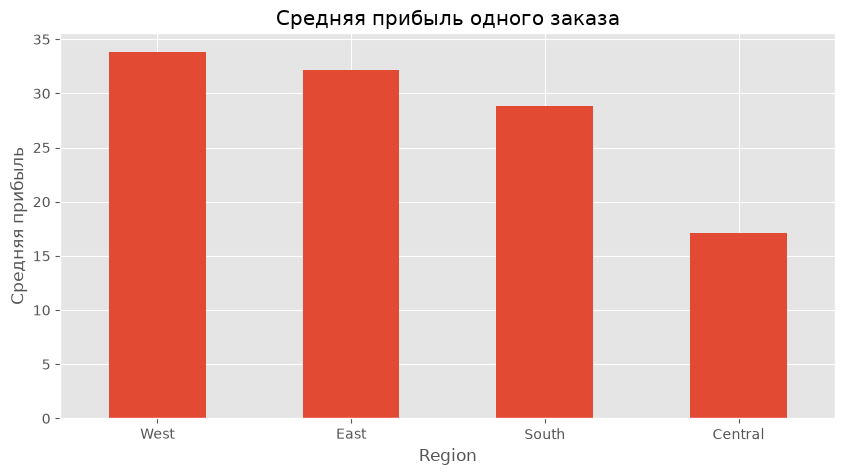

In [53]:
plt.figure(figsize=(10,5))

avg_profit_region.plot(kind="bar")

plt.title("Средняя прибыль одного заказа")

plt.ylabel("Средняя прибыль")

plt.xticks(rotation=0)

plt.show()

In [54]:
state_profit = (
    df.groupby("State")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

state_profit

State
California    76381.3871
New York      74038.5486
Washington    33402.6517
Michigan      24463.1876
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64

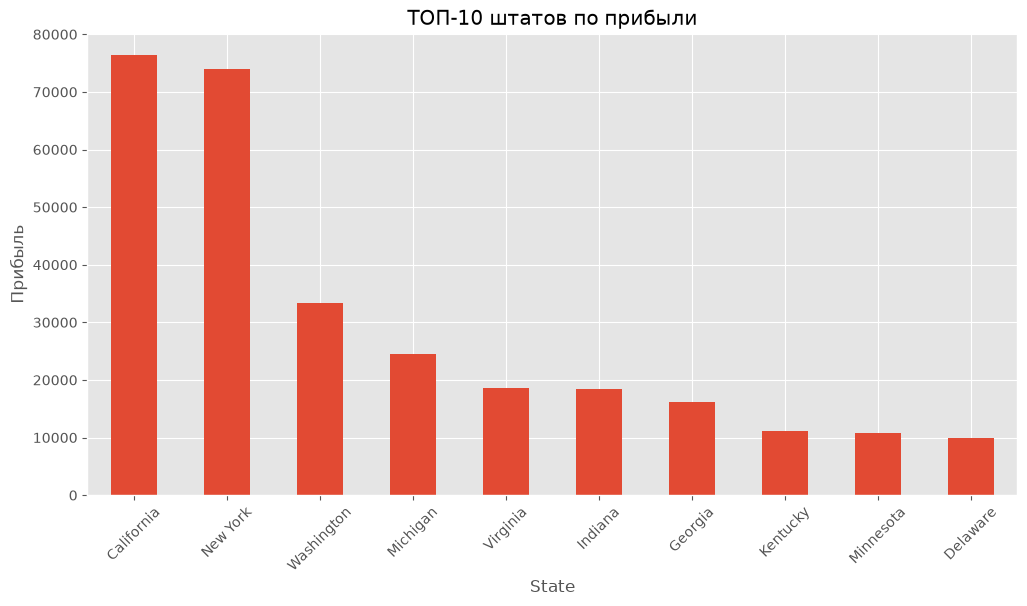

In [55]:
plt.figure(figsize=(12,6))

state_profit.plot(kind="bar")

plt.title("ТОП-10 штатов по прибыли")

plt.ylabel("Прибыль")

plt.xticks(rotation=45)

plt.show()

In [56]:
worst_states = (
    df.groupby("State")["Profit"]
      .sum()
      .sort_values()
      .head(10)
)

worst_states

State
Texas            -25729.3563
Ohio             -16971.3766
Pennsylvania     -15559.9603
Illinois         -12607.8870
North Carolina    -7490.9122
Colorado          -6527.8579
Tennessee         -5341.6936
Arizona           -3427.9246
Florida           -3399.3017
Oregon            -1190.4705
Name: Profit, dtype: float64

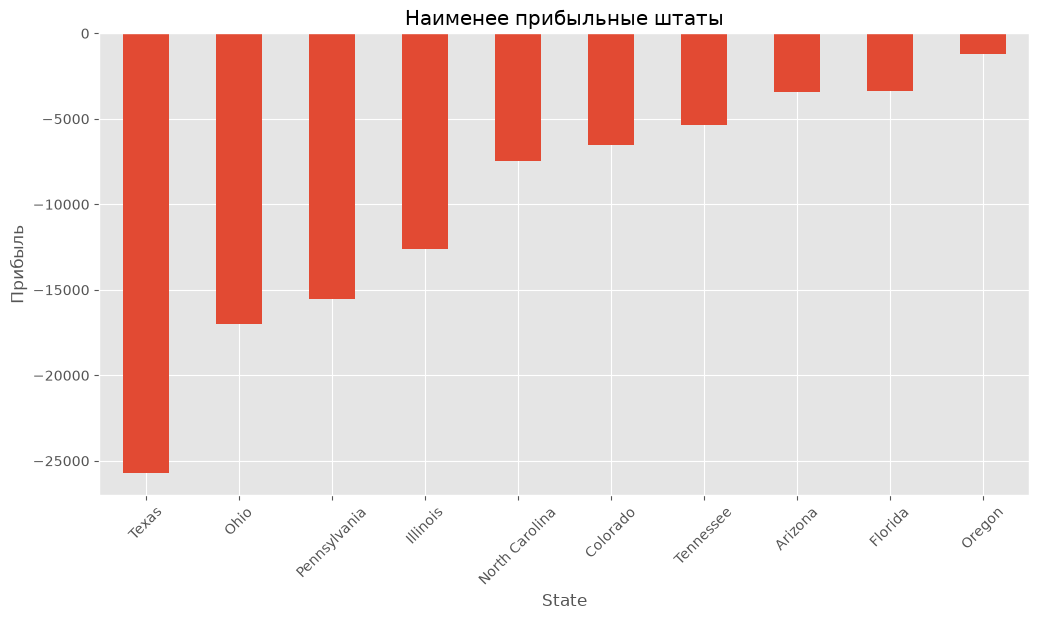

In [57]:
plt.figure(figsize=(12,6))

worst_states.plot(kind="bar")

plt.title("Наименее прибыльные штаты")

plt.ylabel("Прибыль")

plt.xticks(rotation=45)

plt.show()

### Вывод

Полученные результаты показывают, что отдельные штаты являются убыточными.

Даже при наличии продаж компания теряет прибыль.

Возможные причины:

- чрезмерные скидки;
- высокая стоимость логистики;
- особенности ассортимента;
- региональная ценовая политика.

Данные регионы требуют дополнительного исследования.

## Итоги анализа регионов

В результате анализа были выявлены значительные различия между регионами и штатами по объему продаж и прибыли.

Наибольший интерес представляют регионы с высокой выручкой, но относительно низкой прибыльностью. Именно они могут стать точками роста бизнеса при корректировке ценовой политики, системы скидок или логистики.

# 8. Анализ скидок

Одним из факторов, оказывающих влияние на финансовые показатели компании, является система скидок.

В данном разделе проверим гипотезу:

> Увеличение размера скидки приводит к снижению прибыли.

Для этого проанализируем взаимосвязь между размером скидки и прибылью.

In [78]:
df["Discount"].value_counts().sort_index()

Discount
0.00    4798
0.10      94
0.15      52
0.20    3657
0.30     227
0.32      27
0.40     206
0.45      11
0.50      66
0.60     138
0.70     418
0.80     300
Name: count, dtype: int64

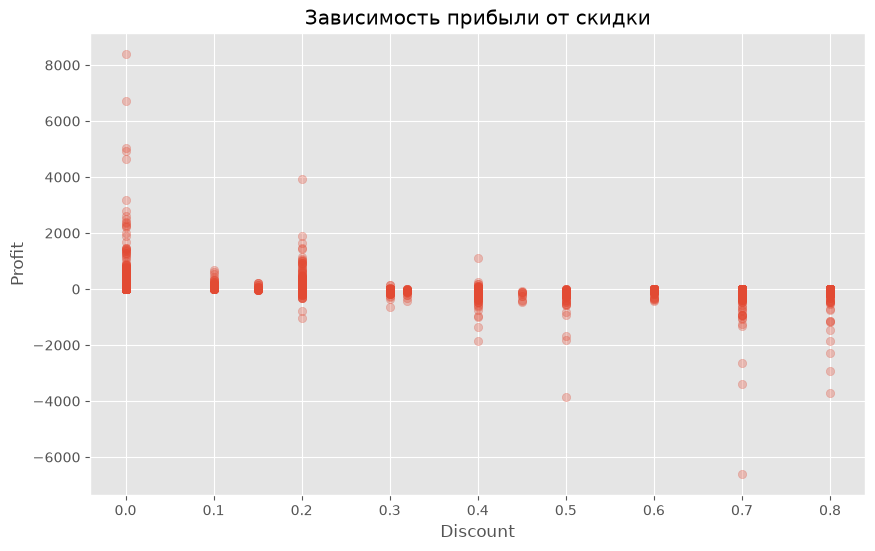

In [79]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.3
)

plt.title("Зависимость прибыли от скидки")

plt.xlabel("Discount")

plt.ylabel("Profit")

plt.show()

### Вывод

По мере увеличения размера скидки наблюдается рост количества убыточных заказов.

Особенно заметно увеличение отрицательной прибыли при скидках выше 20–30%.

In [80]:
corr = df["Discount"].corr(df["Profit"])

print(corr)

-0.219487456371769


### Вывод

Между размером скидки и прибылью наблюдается отрицательная корреляция.

Это означает, что увеличение скидки сопровождается снижением прибыли.

Однако коэффициент корреляции невысокий, следовательно на прибыль также влияют другие факторы.

In [81]:
discount_profit = (
    df.groupby("Discount")["Profit"]
      .mean()
      .reset_index()
)

discount_profit

,Discount,Profit
0,0.00,66.900292
1,0.10,96.055074
2,0.15,27.288298
3,0.20,24.702572
4,0.30,-45.679636
5,0.32,-88.560656
6,0.40,-111.927429
7,0.45,-226.646464
8,0.50,-310.703456
9,0.60,-43.077212


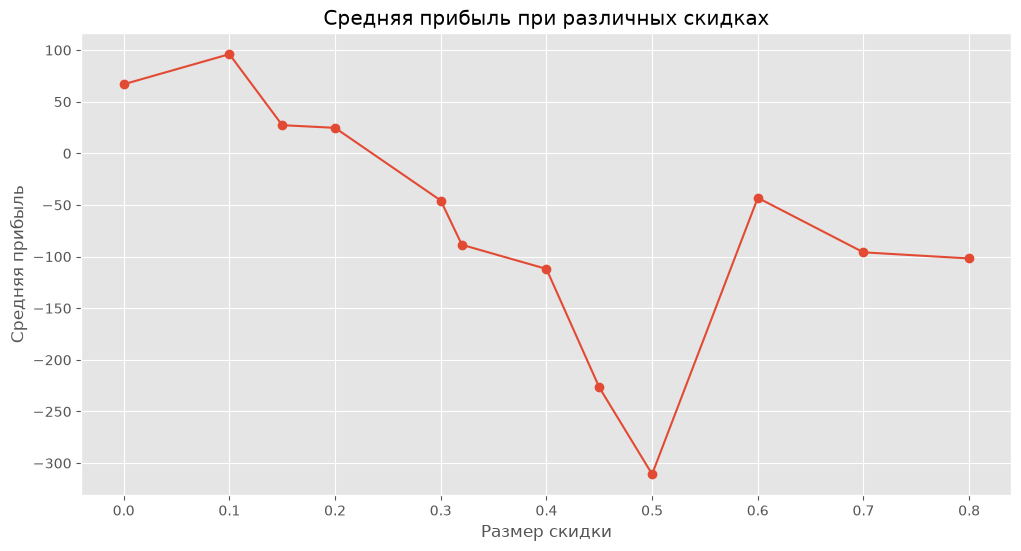

In [82]:
plt.figure(figsize=(12,6))

plt.plot(
    discount_profit["Discount"],
    discount_profit["Profit"],
    marker="o"
)

plt.title("Средняя прибыль при различных скидках")

plt.xlabel("Размер скидки")

plt.ylabel("Средняя прибыль")

plt.grid(True)

plt.show()

In [83]:
df["Loss"] = df["Profit"] < 0

In [84]:
loss_discount = (
    df.groupby("Discount")["Loss"]
      .mean()
      .reset_index()
)

loss_discount

,Discount,Loss
0,0.00,0.000000
1,0.10,0.042553
2,0.15,0.326923
3,0.20,0.137271
4,0.30,0.916300
5,0.32,1.000000
6,0.40,0.873786
7,0.45,1.000000
8,0.50,1.000000
9,0.60,1.000000


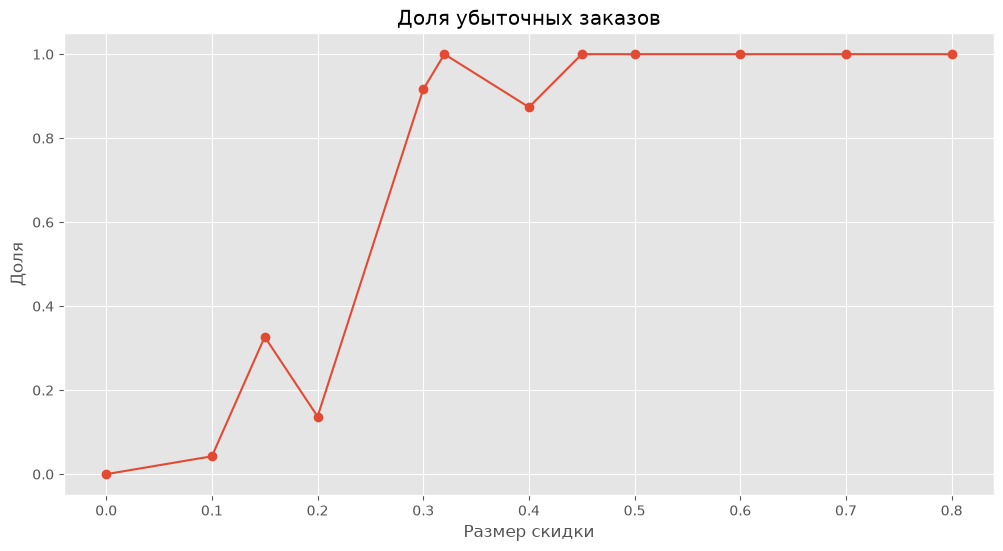

In [85]:
plt.figure(figsize=(12,6))

plt.plot(
    loss_discount["Discount"],
    loss_discount["Loss"],
    marker="o"
)

plt.title("Доля убыточных заказов")

plt.xlabel("Размер скидки")

plt.ylabel("Доля")

plt.grid(True)

plt.show()

In [86]:
discount_summary = (
    df.groupby("Discount")
      .agg(
          Orders=("Order ID","count"),
          Sales=("Sales","sum"),
          AvgProfit=("Profit","mean"),
          TotalProfit=("Profit","sum")
      )
      .round(2)
)

discount_summary

,Orders,Sales,AvgProfit,TotalProfit
Discount,,,,
0.00,4798,1087908.47,66.90,320987.60
0.10,94,54369.35,96.06,9029.18
0.15,52,27558.52,27.29,1418.99
0.20,3657,764594.37,24.70,90337.31
0.30,227,103226.66,-45.68,-10369.28
0.32,27,14493.46,-88.56,-2391.14
0.40,206,116417.78,-111.93,-23057.05
0.45,11,5484.97,-226.65,-2493.11
0.50,66,58918.54,-310.70,-20506.43


## Итоги анализа скидок

Проведенный анализ показал наличие отрицательной зависимости между размером скидки и прибыльностью продаж.

При увеличении скидки:

- уменьшается средняя прибыль;
- возрастает количество убыточных заказов;
- снижается общая эффективность продаж.

Полученные результаты свидетельствуют о необходимости пересмотра политики предоставления крупных скидок.

## Рекомендации

На основании проведенного анализа можно предложить следующие меры:

1. Ограничить применение скидок выше 20–30%.
2. Провести анализ товаров, продаваемых с большими скидками.
3. Рассмотреть альтернативные маркетинговые акции вместо прямого снижения цены.
4. Контролировать прибыльность заказов с высокой скидкой.

# 9. Анализ сезонности

Продажи редко распределяются равномерно в течение года.

Цель данного раздела — определить наличие сезонности и выявить периоды максимальной и минимальной активности покупателей.

В рамках анализа ответим на следующие вопросы:

- Как меняются продажи по месяцам?
- В какие месяцы компания получает максимальную прибыль?
- Наблюдаются ли сезонные пики продаж?

In [69]:
monthly_sales = (
    df.groupby("Month", as_index=False)
      .agg(
          Sales=("Sales","sum"),
          Profit=("Profit","sum"),
          Orders=("Order ID","nunique")
      )
)

monthly_sales

,Month,Sales,Profit,Orders
0,1,94924.8356,9134.4461,178
1,2,59751.2514,10294.6107,162
2,3,205005.4888,28594.6872,354
3,4,137762.1286,11587.4363,343
4,5,155028.8117,22411.3078,369
5,6,152718.6793,21285.7954,364
6,7,147238.0970,13832.6648,338
7,8,159044.0630,21776.9384,341
8,9,307649.9457,36857.4753,688
9,10,200322.9847,31784.0413,417


In [70]:
months = {
1:"January",
2:"February",
3:"March",
4:"April",
5:"May",
6:"June",
7:"July",
8:"August",
9:"September",
10:"October",
11:"November",
12:"December"
}

monthly_sales["Month"] = monthly_sales["Month"].map(months)

monthly_sales

,Month,Sales,Profit,Orders
0,January,94924.8356,9134.4461,178
1,February,59751.2514,10294.6107,162
2,March,205005.4888,28594.6872,354
3,April,137762.1286,11587.4363,343
4,May,155028.8117,22411.3078,369
5,June,152718.6793,21285.7954,364
6,July,147238.0970,13832.6648,338
7,August,159044.0630,21776.9384,341
8,September,307649.9457,36857.4753,688
9,October,200322.9847,31784.0413,417


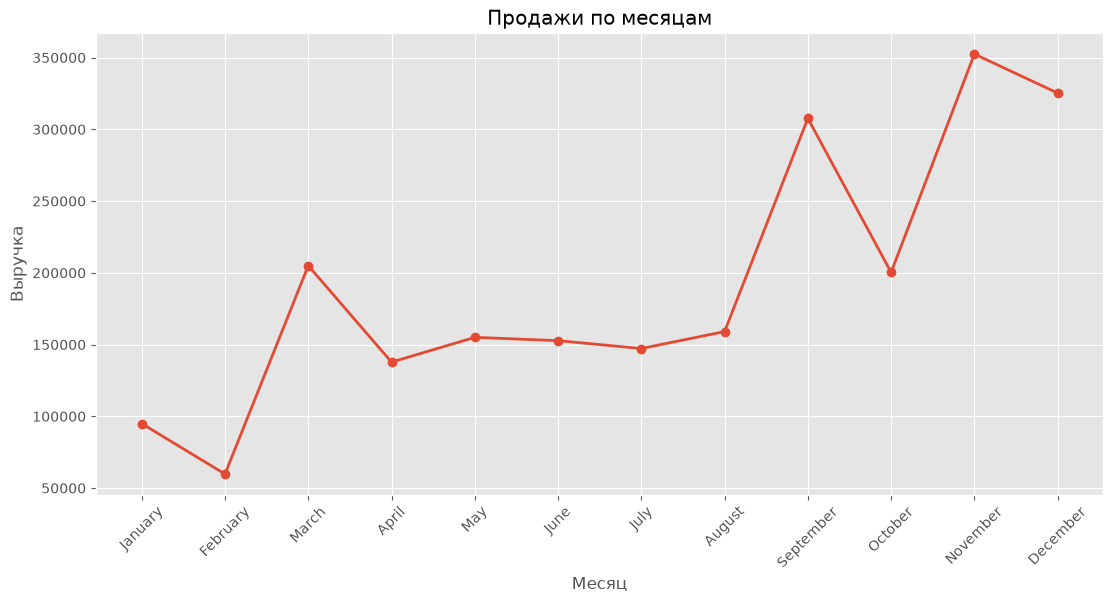

In [71]:
plt.figure(figsize=(13,6))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2
)

plt.title("Продажи по месяцам")

plt.xlabel("Месяц")

plt.ylabel("Выручка")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

### Вывод

Продажи распределены неравномерно в течение года.

Наблюдаются выраженные пики продаж, что свидетельствует о наличии сезонности.

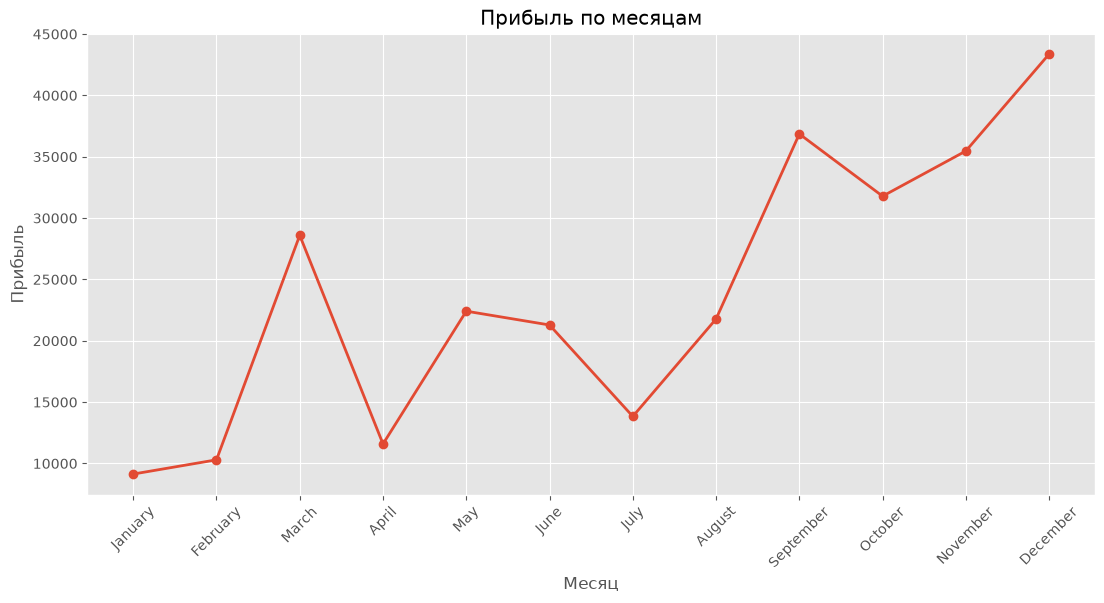

In [72]:
plt.figure(figsize=(13,6))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Profit"],
    marker="o",
    linewidth=2
)

plt.title("Прибыль по месяцам")

plt.xlabel("Месяц")

plt.ylabel("Прибыль")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

### Вывод

Максимальная прибыль наблюдается в конце года.

Вероятно, увеличение прибыли связано с сезонным ростом спроса и праздничными распродажами.

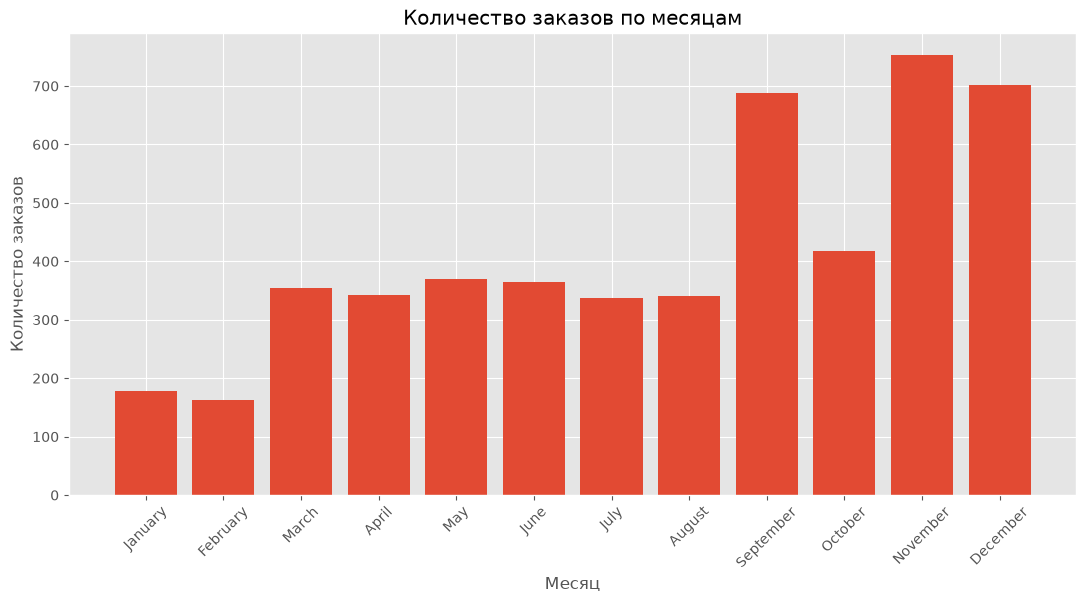

In [73]:
plt.figure(figsize=(13,6))

plt.bar(
    monthly_sales["Month"],
    monthly_sales["Orders"]
)

plt.title("Количество заказов по месяцам")

plt.xlabel("Месяц")

plt.ylabel("Количество заказов")

plt.xticks(rotation=45)

plt.show()

In [74]:
monthly_sales["Average Order"] = (
    monthly_sales["Sales"] /
    monthly_sales["Orders"]
)

monthly_sales

,Month,Sales,Profit,Orders,Average Order
0,January,94924.8356,9134.4461,178,533.285593
1,February,59751.2514,10294.6107,162,368.834885
2,March,205005.4888,28594.6872,354,579.111550
3,April,137762.1286,11587.4363,343,401.638859
4,May,155028.8117,22411.3078,369,420.132281
5,June,152718.6793,21285.7954,364,419.556811
6,July,147238.0970,13832.6648,338,435.615672
7,August,159044.0630,21776.9384,341,466.404877
8,September,307649.9457,36857.4753,688,447.165619
9,October,200322.9847,31784.0413,417,480.390851


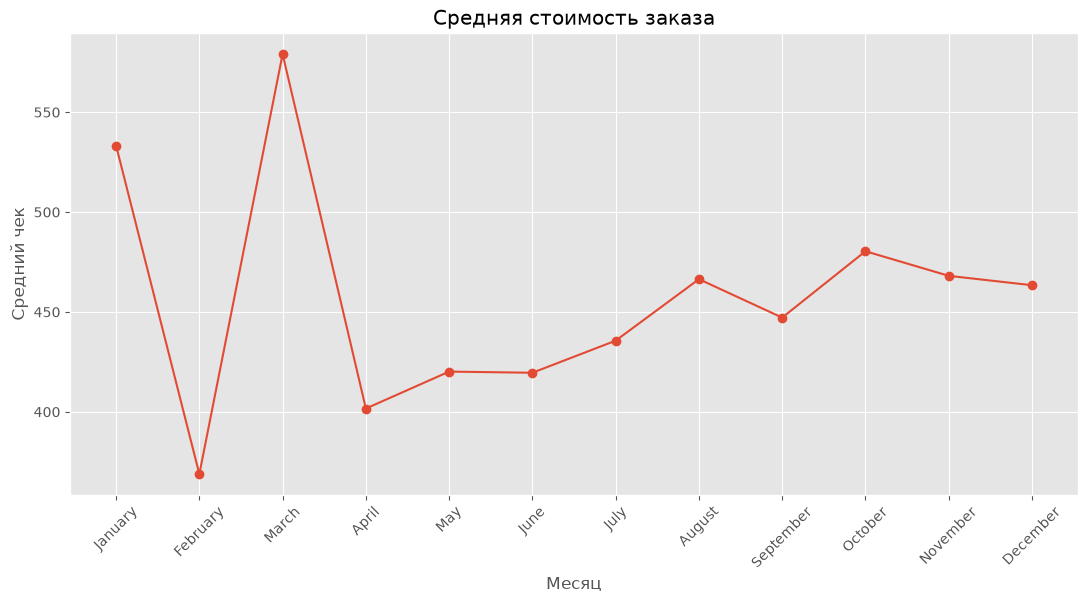

In [75]:
plt.figure(figsize=(13,6))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Average Order"],
    marker="o"
)

plt.title("Средняя стоимость заказа")

plt.xlabel("Месяц")

plt.ylabel("Средний чек")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [76]:
monthly_sales.sort_values(
    by="Profit",
    ascending=False
).head(1)

,Month,Sales,Profit,Orders,Average Order
11,December,325293.5035,43369.1919,702,463.381059


In [77]:
monthly_sales.sort_values(
    by="Profit"
).head(1)

,Month,Sales,Profit,Orders,Average Order
0,January,94924.8356,9134.4461,178,533.285593


## Итоги анализа сезонности

Проведенный анализ подтвердил наличие сезонности в продажах.

Основные наблюдения:

- объем продаж изменяется в течение года;
- прибыль достигает максимума в отдельные месяцы;
- количество заказов также имеет сезонные колебания;
- изменение среднего чека указывает на различия в покупательском поведении.

Полученные результаты рекомендуется учитывать при планировании рекламных кампаний, закупок и управления запасами.

## Рекомендации

По результатам анализа можно предложить следующие меры:

- увеличить маркетинговую активность перед периодами максимального спроса;
- заранее планировать закупку наиболее популярных товаров;
- использовать периоды низкого спроса для проведения маркетинговых акций;
- учитывать сезонность при прогнозировании продаж.

# 10. Анализ клиентов

Клиенты являются главным источником дохода компании. Однако не все клиенты приносят одинаковую прибыль.

В данном разделе необходимо определить:

- какие сегменты клиентов наиболее прибыльны;
- кто приносит наибольшую выручку;
- кто совершает больше всего покупок;
- какие клиенты являются наиболее ценными для бизнеса.

In [87]:
segment = (
    df.groupby("Segment")
      .agg(
          Sales=("Sales","sum"),
          Profit=("Profit","sum"),
          Orders=("Order ID","nunique"),
          Customers=("Customer ID","nunique")
      )
)

segment

,Sales,Profit,Orders,Customers
Segment,,,,
Consumer,1.161401e+06,134119.2092,2586,409
Corporate,7.061464e+05,91979.1340,1514,236
Home Office,4.296531e+05,60298.6785,909,148


In [88]:
segment["Profit per Customer"] = (
    segment["Profit"] /
    segment["Customers"]
)

segment.round(2)

,Sales,Profit,Orders,Customers,Profit per Customer
Segment,,,,,
Consumer,1161401.34,134119.21,2586,409,327.92
Corporate,706146.37,91979.13,1514,236,389.74
Home Office,429653.15,60298.68,909,148,407.42


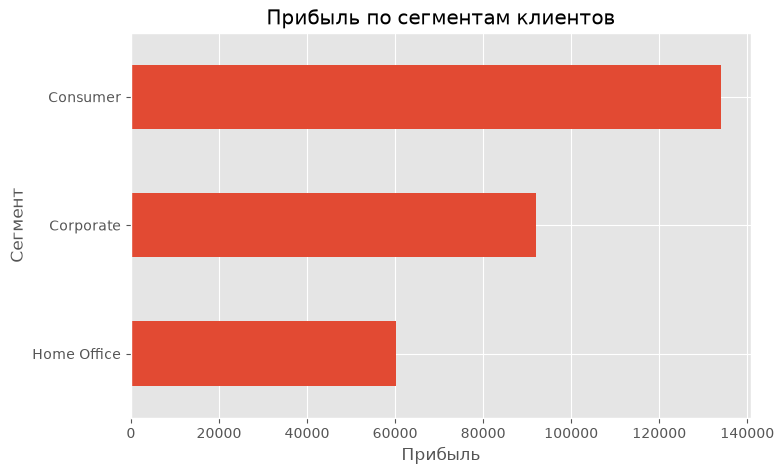

In [89]:
plt.figure(figsize=(8,5))

segment["Profit"].sort_values().plot(kind="barh")

plt.title("Прибыль по сегментам клиентов")

plt.xlabel("Прибыль")

plt.ylabel("Сегмент")

plt.show()

### Вывод

Сегменты клиентов значительно различаются по объему продаж и прибыли.

Наиболее прибыльный сегмент представляет наибольшую ценность для компании и должен стать приоритетным при разработке маркетинговых мероприятий.

In [90]:
top_profit = (
    df.groupby("Customer Name")
      .agg(
          Sales=("Sales","sum"),
          Profit=("Profit","sum"),
          Orders=("Order ID","nunique")
      )
      .sort_values("Profit",ascending=False)
      .head(10)
)

top_profit

,Sales,Profit,Orders
Customer Name,,,
Tamara Chand,19052.218,8981.3239,5
Raymond Buch,15117.339,6976.0959,6
Sanjit Chand,14142.334,5757.4119,9
Hunter Lopez,12873.298,5622.4292,6
Adrian Barton,14473.571,5444.8055,10
Tom Ashbrook,14595.620,4703.7883,4
Christopher Martinez,8954.020,3899.8904,4
Keith Dawkins,8181.256,3038.6254,12
Andy Reiter,6608.448,2884.6208,6


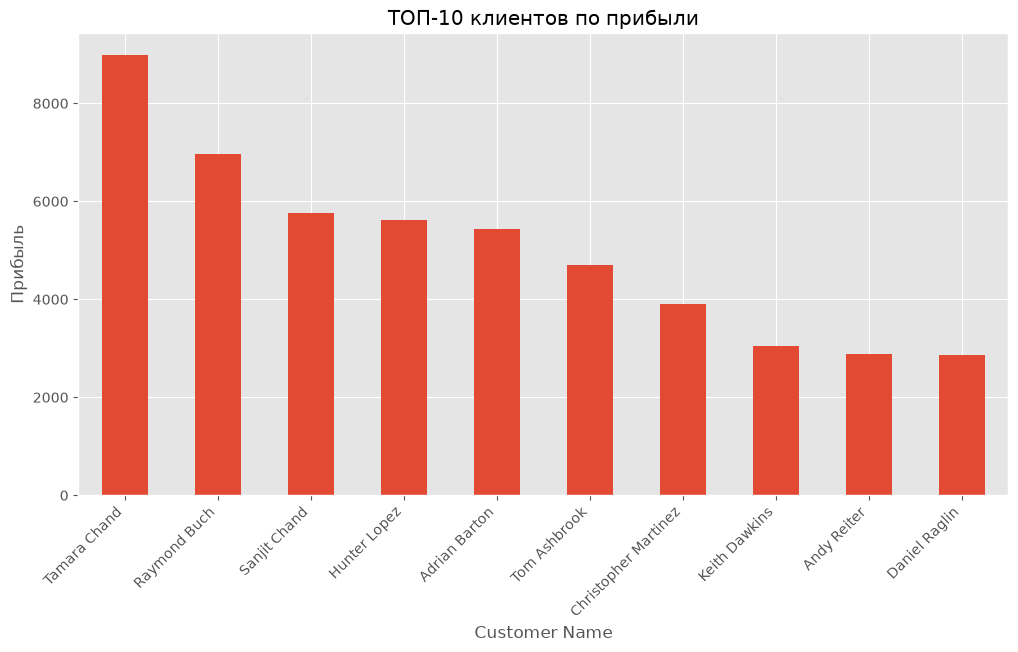

In [91]:
plt.figure(figsize=(12,6))

top_profit["Profit"].plot(kind="bar")

plt.title("ТОП-10 клиентов по прибыли")

plt.ylabel("Прибыль")

plt.xticks(rotation=45, ha="right")

plt.show()

### Вывод

Небольшая группа клиентов приносит компании существенную часть прибыли.

Для подобных клиентов рекомендуется разработать программы лояльности и персональные предложения.

In [92]:
top_sales = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_sales

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

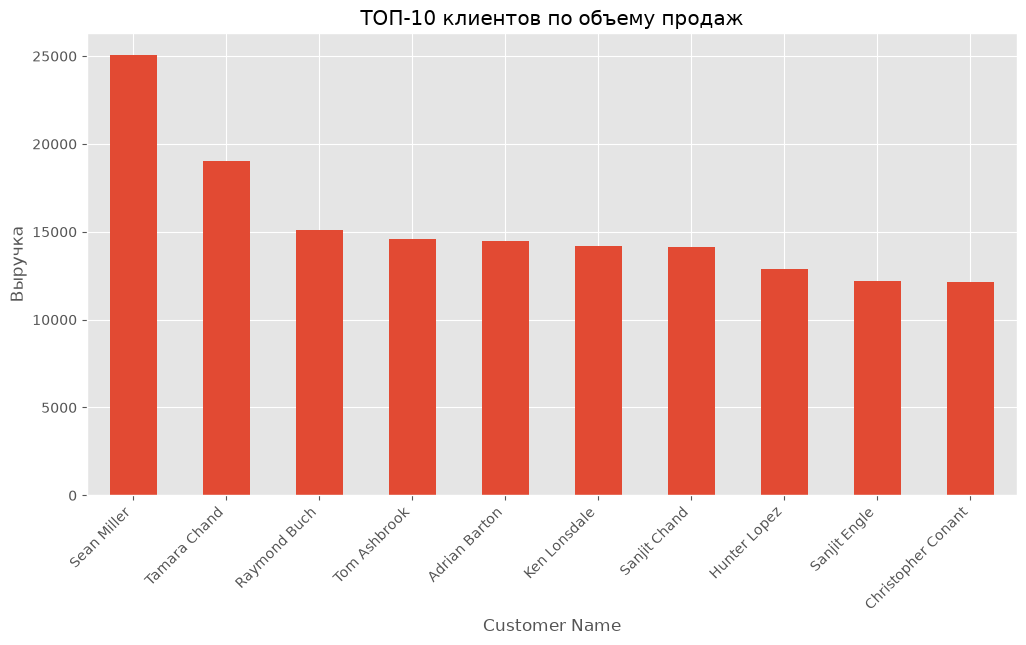

In [93]:
plt.figure(figsize=(12,6))

top_sales.plot(kind="bar")

plt.title("ТОП-10 клиентов по объему продаж")

plt.ylabel("Выручка")

plt.xticks(rotation=45, ha="right")

plt.show()

In [94]:
top_orders = (
    df.groupby("Customer Name")["Order ID"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

top_orders

Customer Name
Emily Phan             17
Sally Hughsby          13
Noel Staavos           13
Patrick Gardner        13
Zuschuss Carroll       13
Joel Eaton             13
Erin Ashbrook          13
Chloris Kastensmidt    13
Suzanne McNair         12
Rick Bensley           12
Name: Order ID, dtype: int64

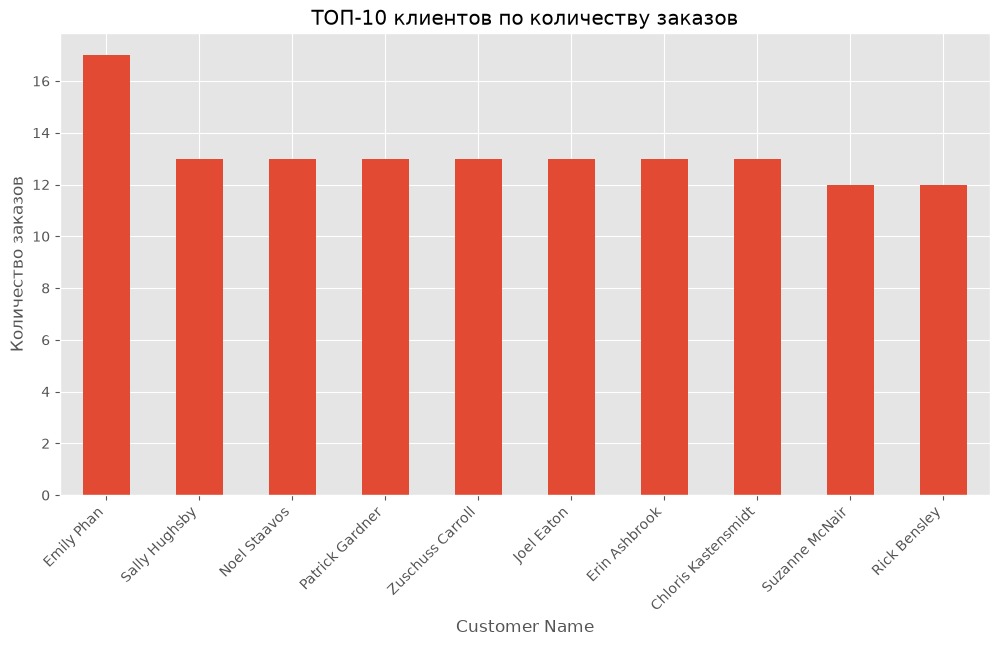

In [95]:
plt.figure(figsize=(12,6))

top_orders.plot(kind="bar")

plt.title("ТОП-10 клиентов по количеству заказов")

plt.ylabel("Количество заказов")

plt.xticks(rotation=45, ha="right")

plt.show()

In [96]:
segment_avg = (
    df.groupby("Segment")
      .agg(
          Sales=("Sales","sum"),
          Orders=("Order ID","nunique")
      )
)

segment_avg["Average Check"] = (
    segment_avg["Sales"] /
    segment_avg["Orders"]
)

segment_avg.round(2)

,Sales,Orders,Average Check
Segment,,,
Consumer,1161401.34,2586,449.11
Corporate,706146.37,1514,466.41
Home Office,429653.15,909,472.67


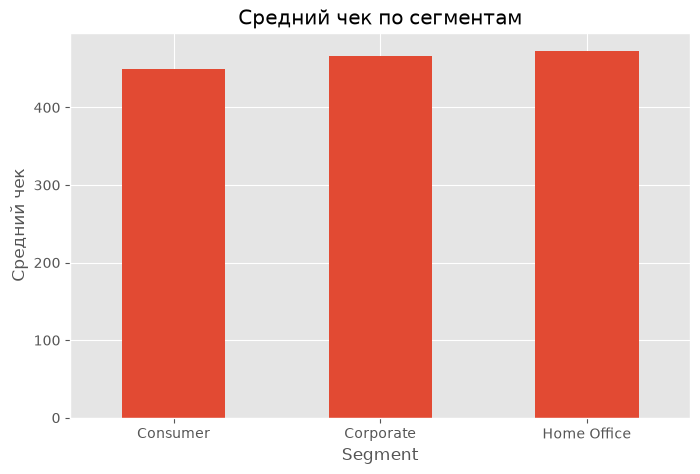

In [97]:
plt.figure(figsize=(8,5))

segment_avg["Average Check"].plot(kind="bar")

plt.title("Средний чек по сегментам")

plt.ylabel("Средний чек")

plt.xticks(rotation=0)

plt.show()

## Итоги анализа клиентов

Проведенный анализ показал, что вклад клиентов в финансовые показатели компании существенно различается.

Основные выводы:

- наиболее прибыльный сегмент формирует основную часть прибыли;
- небольшая группа клиентов обеспечивает значительную долю продаж;
- существуют постоянные клиенты с высокой частотой заказов;
- средний чек отличается между сегментами.

Полученные результаты могут использоваться для разработки программ лояльности и персонализированных маркетинговых предложений.

## Рекомендации

По результатам анализа рекомендуется:

- разработать программы удержания наиболее прибыльных клиентов;
- использовать персональные предложения для клиентов с высоким средним чеком;
- стимулировать повторные покупки клиентов с низкой частотой заказов;
- сегментировать маркетинговые кампании по типам клиентов.

In [98]:
df["Delivery Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

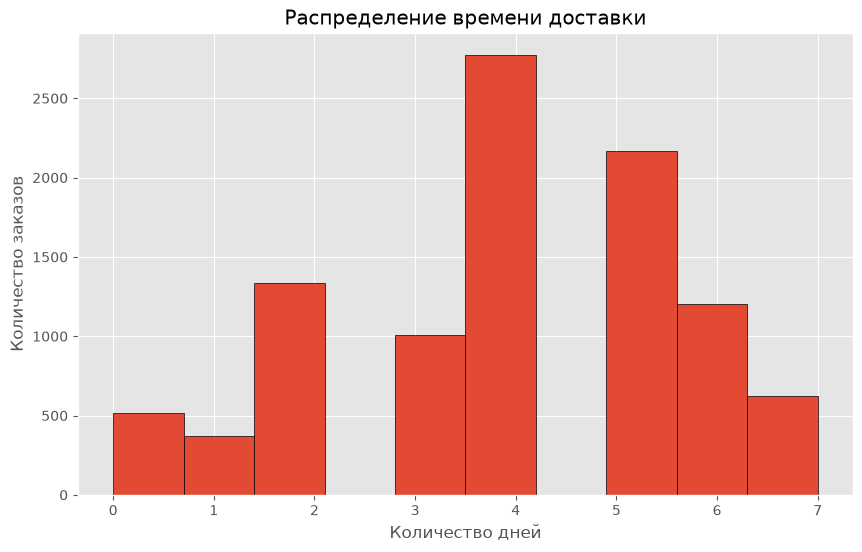

In [99]:
plt.figure(figsize=(10,6))

plt.hist(
    df["Delivery Days"],
    bins=10,
    edgecolor="black"
)

plt.title("Распределение времени доставки")

plt.xlabel("Количество дней")

plt.ylabel("Количество заказов")

plt.show()

In [100]:
delivery = (
    df.groupby("Ship Mode")
      .agg(
          AvgDelivery=("Delivery Days","mean")
      )
      .sort_values("AvgDelivery")
)

delivery

,AvgDelivery
Ship Mode,
Same Day,0.044199
First Class,2.182705
Second Class,3.238046
Standard Class,5.006535


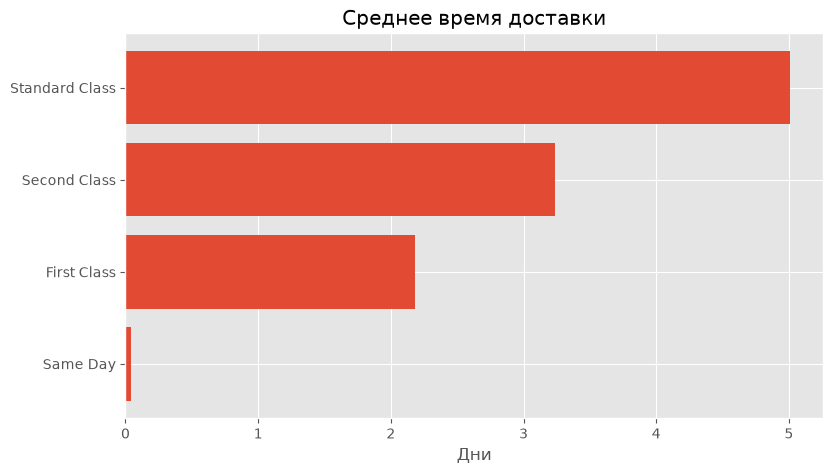

In [101]:
plt.figure(figsize=(9,5))

plt.barh(
    delivery.index,
    delivery["AvgDelivery"]
)

plt.title("Среднее время доставки")

plt.xlabel("Дни")

plt.show()

In [102]:
profit_ship = (
    df.groupby("Ship Mode")["Profit"]
      .mean()
      .sort_values()
)

profit_ship

Ship Mode
Standard Class    27.494770
Same Day          29.266591
Second Class      29.535545
First Class       31.839948
Name: Profit, dtype: float64

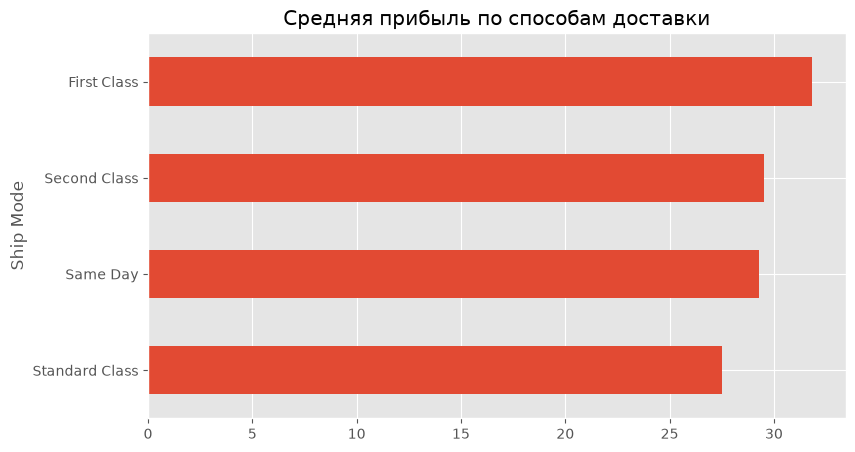

In [103]:
plt.figure(figsize=(9,5))

profit_ship.plot(kind="barh")

plt.title("Средняя прибыль по способам доставки")

plt.show()

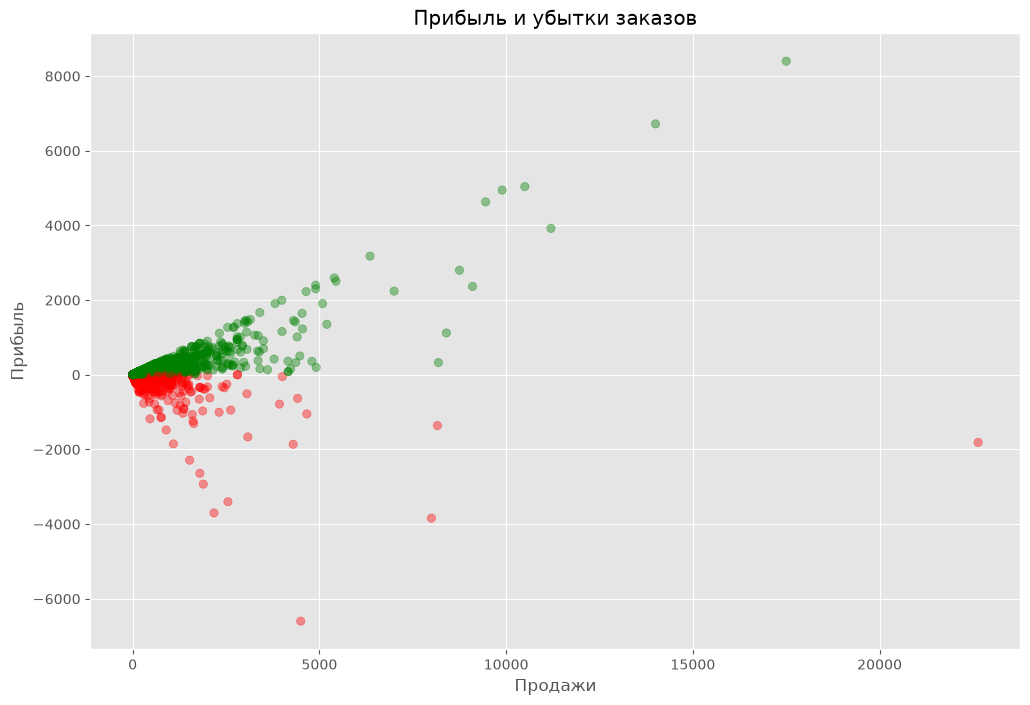

In [105]:
colors = np.where(
    df["Profit"] > 0,
    "green",
    "red"
)

plt.figure(figsize=(12,8))

plt.scatter(
    df["Sales"],
    df["Profit"],
    c=colors,
    alpha=0.4
)

plt.title("Прибыль и убытки заказов")

plt.xlabel("Продажи")

plt.ylabel("Прибыль")

plt.show()

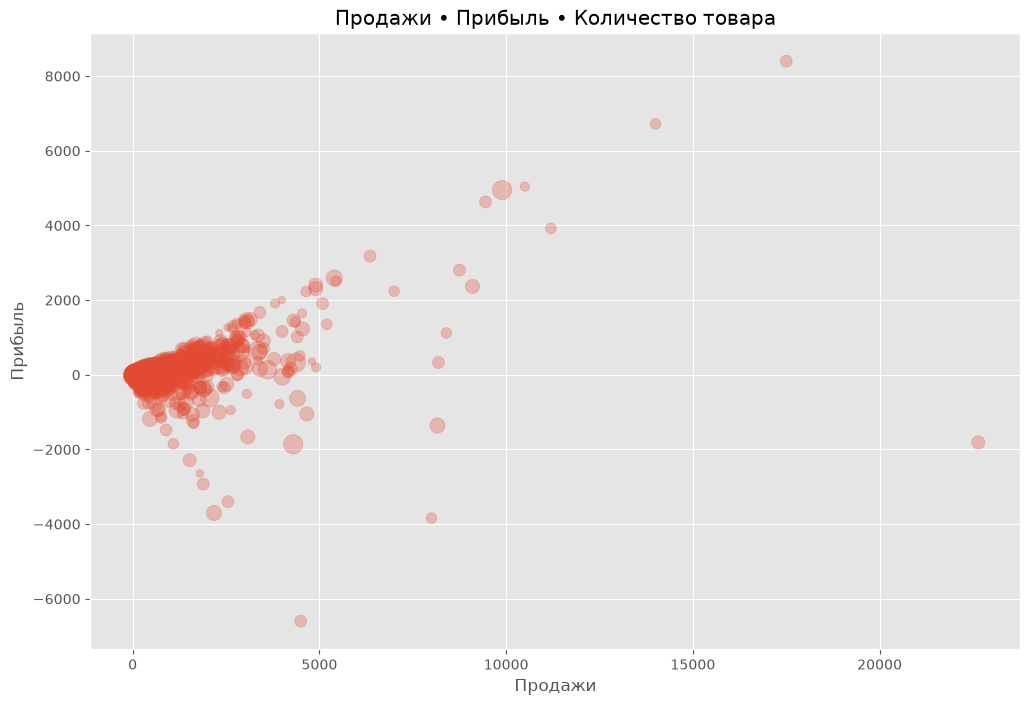

In [106]:
plt.figure(figsize=(12,8))

plt.scatter(
    df["Sales"],
    df["Profit"],
    s=df["Quantity"]*15,
    alpha=0.3
)

plt.title("Продажи • Прибыль • Количество товара")

plt.xlabel("Продажи")

plt.ylabel("Прибыль")

plt.show()

In [107]:
corr = df[
    [
        "Sales",
        "Profit",
        "Discount",
        "Quantity",
        "Delivery Days"
    ]
].corr()

corr

,Sales,Profit,Discount,Quantity,Delivery Days
Sales,1.000000,0.479064,-0.028190,0.200795,-0.007354
Profit,0.479064,1.000000,-0.219487,0.066253,-0.004649
Discount,-0.028190,-0.219487,1.000000,0.008623,0.000408
Quantity,0.200795,0.066253,0.008623,1.000000,0.018298
Delivery Days,-0.007354,-0.004649,0.000408,0.018298,1.000000


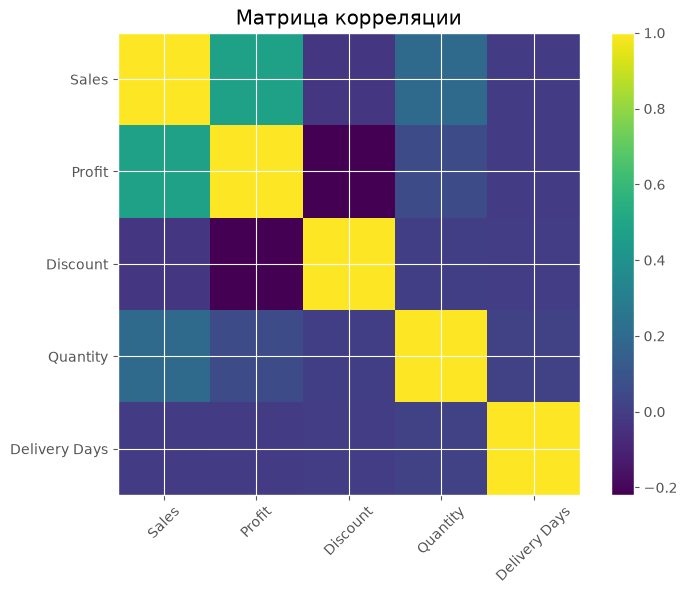

In [108]:
plt.figure(figsize=(8,6))

plt.imshow(
    corr,
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Матрица корреляции")

plt.show()

In [109]:
top_products = (
    df.groupby("Product Name")
      .agg(
          Sales=("Sales","sum"),
          Profit=("Profit","sum")
      )
      .sort_values("Profit",ascending=False)
      .head(15)
)

top_products

,Sales,Profit
Product Name,,
Canon imageCLASS 2200 Advanced Copier,61599.824,25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7753.0390
Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836
Canon PC1060 Personal Laser Copier,11619.834,4570.9347
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4094.9766
Ativa V4110MDD Micro-Cut Shredder,7699.890,3772.9461
"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System,9367.290,3696.2820
Ibico EPK-21 Electric Binding System,15875.916,3345.2823


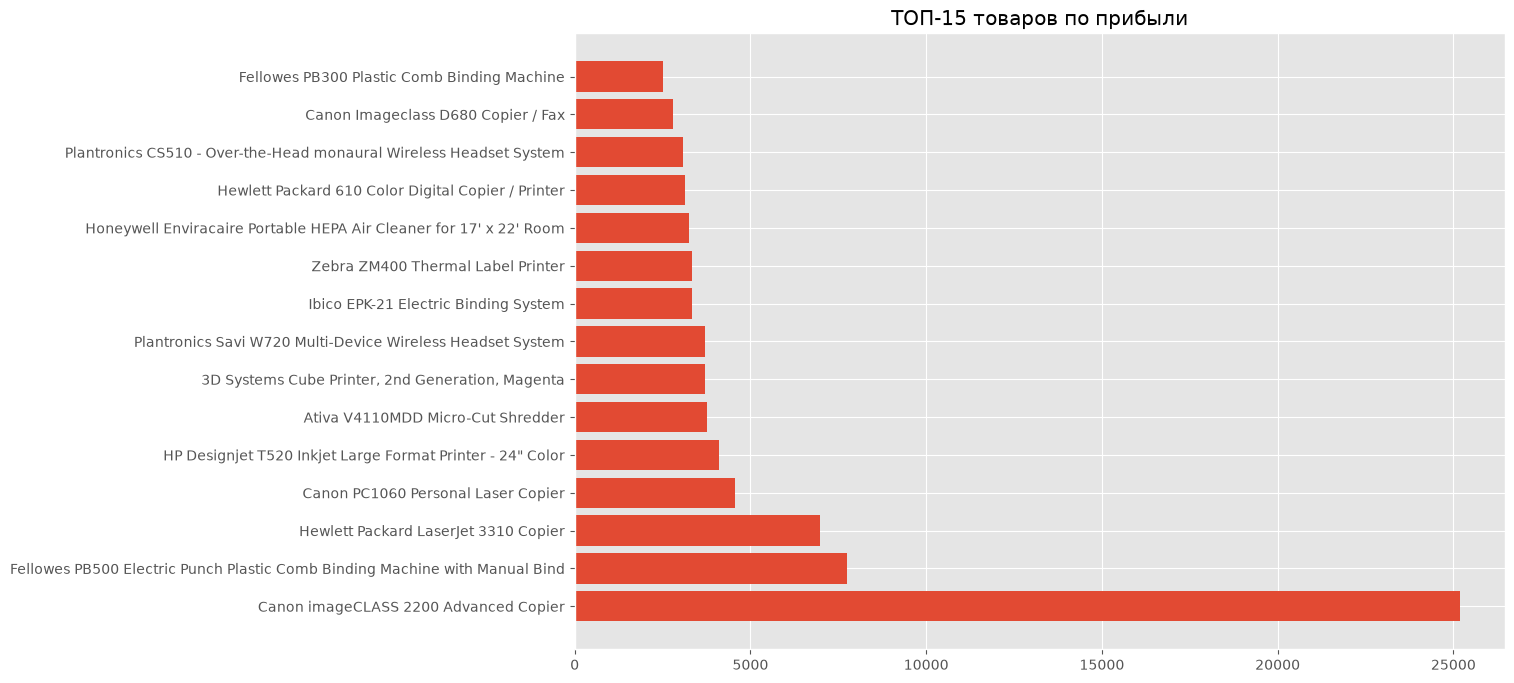

In [110]:
plt.figure(figsize=(12,8))

plt.barh(
    top_products.index,
    top_products["Profit"]
)

plt.title("ТОП-15 товаров по прибыли")

plt.show()

In [111]:
worst_products = (
    df.groupby("Product Name")["Profit"]
      .sum()
      .sort_values()
      .head(15)
)

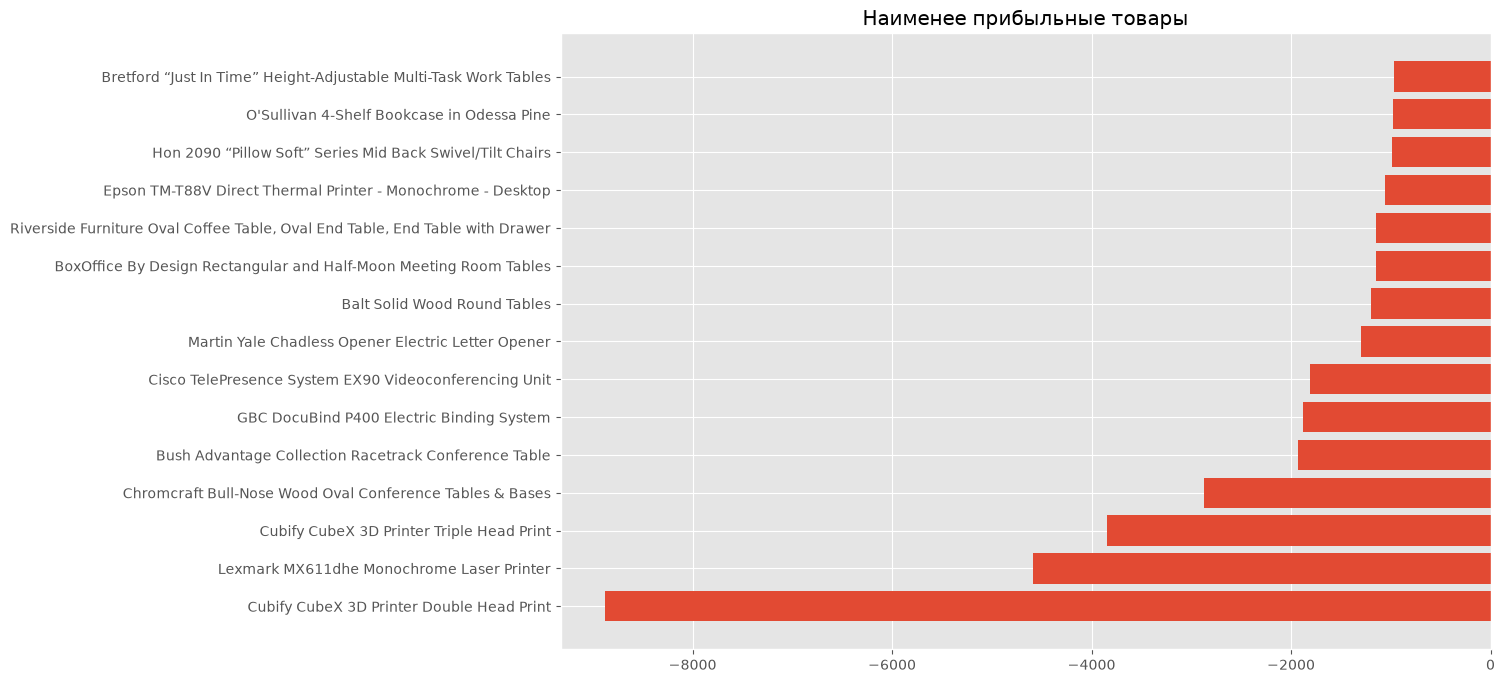

In [112]:
plt.figure(figsize=(12,8))

plt.barh(
    worst_products.index,
    worst_products.values
)

plt.title("Наименее прибыльные товары")

plt.show()

# Executive Summary

## Основные результаты

Проведен анализ 9994 заказов интернет-магазина.

В ходе исследования установлено:

✔ Компания получила выручку более 2 млн долларов.

✔ Наиболее прибыльной категорией является Technology.

✔ Подкатегории Tables и Bookcases являются убыточными.

✔ Максимальная прибыль наблюдается в регионе West.

✔ Высокие скидки сопровождаются снижением прибыли.

✔ Большинство заказов доставляется за 4 дня.

✔ Значительная часть прибыли формируется небольшой группой постоянных клиентов.

---

## Практические рекомендации

1. Ограничить скидки выше 20%.

2. Пересмотреть ассортимент убыточных товаров.

3. Усилить маркетинг наиболее прибыльных категорий.

4. Разработать программу лояльности для ключевых клиентов.

5. Использовать сезонные пики продаж при планировании закупок.

6. Контролировать прибыльность регионов с высоким объемом продаж.